# Product Matching Pipeline (Candidate Pairs → Features → Model)

This notebook builds an end-to-end *product matching* baseline using:

- **Data loading + quality checks**
- **Text normalization / cleaning**
- **Candidate generation** using brand blocking + char n-gram TF-IDF + nearest neighbors
- **Feature engineering** for pairwise similarity
- **Weak supervision** (high-confidence pseudo-labels) to bootstrap a model
- **Model training** (Logistic Regression) + basic evaluation
- **Scoring all candidate pairs** + score distributions

It is designed to run without extra pip installs.


## 0) Imports

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix

pd.set_option('display.max_colwidth', 120)


## 1) Load data

In [5]:
products_df = pd.read_csv('standardized_products.csv', encoding='utf-8')

print('Shape:')
print(products_df.shape)
print('Head:')
display(products_df.head())


Shape:
(10378, 16)
Head:


,source,brand,packaging_type,packaging_material,variant_nl,variant_en,net_content_value,net_content_unit,short_name_nl,short_name_en,functional_name_nl,functional_name_en,description_nl,description_en,commercial_name_nl,commercial_name_en
0,unilever,NEUTRAL,BX,WOOD_OTHER,NaN,NaN,NaN,NaN,NEUTRAL LIQUID HANDSOAP 250,NEUTRAL LIQUID HANDSOAP 250,Huidverzorging,PW LIQUIDS,Neutral Liquid Handsoap 250ML 6x,NEUTRAL LS LIQ 0% BOTTL 250ML NL/NOR 23,Neutral Huidverzorging,Neutral PW LIQUIDS
1,unilever,NEUTRAL,BO,POLYMER_HDPE,0%,NaN,NaN,NaN,NEUTRAL LIQUID HANDSOAP 250,NEUTRAL LIQUID HANDSOAP 250,Handzeep,PW LIQUIDS,Neutral Liquid Handsoap 250ML 6x,NEUTRAL LS LIQ 0% BOTTL 250ML NL/NOR 23,Neutral 0% Hand Wash 250 ml Fles,Neutral PW LIQUIDS 250 ML
2,unilever,Unox,PX,POLYMER_LDPE,CHINESEKIP,NaN,NaN,NaN,UNOX CAS CHINESE KIP 21X175,UNOX CAS CHINESE KIP 21X175,Cup A Soup,Cup A Soup,Unox CAS Chinese Kip 21x175ML 4x,UNOX CAS CHINCHIC 4X21X12G BOX DB NLBE,Unox CHINESEKIP Cup A Soup,Unox Cup A Soup
3,unilever,Unox,CS,COMPOSITE,CHINESEKIP,NaN,NaN,NaN,UNOX CAS CHINESE KIP 21X175,UNOX CAS CHINESE KIP 21X175,Cup A Soup,Cup A Soup,Unox CAS Chinese Kip 21x175ML 4x,UNOX CAS CHINCHIC 4X21X12G BOX DB NLBE,Unox CHINESEKIP Cup A Soup,Unox Cup A Soup
4,unilever,Unox,BX,COMPOSITE,CHINESEKIP,NaN,NaN,NaN,UNOX CAS CHINESE KIP 21X175,UNOX CAS CHINESE KIP 21X175,Cup A Soup,Cup A Soup,Unox CAS Chinese Kip 21x175ML 4x,UNOX CAS CHINCHIC 4X21X12G BOX DB NLBE,Unox CHINESEKIP Cup A Soup 252 GR,Unox Cup A Soup 252 GR


## 2) Data quality snapshot

We quantify missingness and uniqueness per field to understand which signals are available for matching.


In [7]:
cols_core = ['source','brand','packaging_type','packaging_material','variant_nl','variant_en',
             'net_content_value','net_content_unit','short_name_nl','short_name_en',
             'functional_name_nl','functional_name_en','description_nl','description_en',
             'commercial_name_nl','commercial_name_en']

quality_df = pd.DataFrame({
    'col': cols_core,
    'missing_pct': [products_df[c].isna().mean() for c in cols_core],
    'n_unique': [products_df[c].nunique(dropna=True) for c in cols_core]
}).sort_values('missing_pct', ascending=False)

print(quality_df)

print('net_content_value summary (non-null numeric):')
val_series = pd.to_numeric(products_df['net_content_value'], errors='coerce')
print(val_series.describe())

print('Top net_content_unit:')
print(products_df['net_content_unit'].value_counts(dropna=False).head(15))


                   col  missing_pct  n_unique
6    net_content_value     0.929466       219
7     net_content_unit     0.929466         7
5           variant_en     0.480150       803
4           variant_nl     0.378686      1836
3   packaging_material     0.280979        22
15  commercial_name_en     0.110040      3544
9        short_name_en     0.109848      3658
13      description_en     0.106572      3881
11  functional_name_en     0.106572       174
14  commercial_name_nl     0.060320      4138
8        short_name_nl     0.000578      4156
10  functional_name_nl     0.000482       492
2       packaging_type     0.000096        29
12      description_nl     0.000096      4290
1                brand     0.000000        93
0               source     0.000000         4
net_content_value summary (non-null numeric):
count       732.000000
mean        729.719822
std        7762.173086
min           1.000000
25%          81.000000
50%         168.500000
75%         300.000000
max      20

## 3) Text cleaning + canonical name field

We pick a single text field per row (best available name/description) and normalize it.


In [9]:
text_cols_pref = [
    'commercial_name_en','commercial_name_nl',
    'short_name_en','short_name_nl',
    'description_en','description_nl',
    'functional_name_en','functional_name_nl',
    'brand'
]

def pick_first_nonnull(row_vals):
    for v in row_vals:
        if pd.notna(v) and str(v).strip() != '':
            return str(v)
    return ''

def normalize_text(txt):
    txt = '' if txt is None else str(txt)
    txt = txt.lower()
    txt = txt.replace('&', ' and ')
    txt = re.sub(r'[^a-z0-9]+', ' ', txt)
    txt = re.sub(r'\s+', ' ', txt).strip()
    return txt

work_df = products_df.copy()

picked_text = []
for _, r in work_df[text_cols_pref].iterrows():
    picked_text.append(pick_first_nonnull(r.values))

work_df['name_raw'] = picked_text
work_df['name_norm'] = work_df['name_raw'].map(normalize_text)

work_df['brand_norm'] = work_df['brand'].fillna('').map(normalize_text)
work_df['pack_type'] = work_df['packaging_type'].fillna('')
work_df['pack_mat'] = work_df['packaging_material'].fillna('')

work_df['net_val_num'] = pd.to_numeric(work_df['net_content_value'], errors='coerce')
work_df['net_unit'] = work_df['net_content_unit'].fillna('')

display(work_df[['brand','name_raw','name_norm','packaging_type','packaging_material','net_content_value','net_content_unit']].head(12))

print('Non-empty name_norm pct:')
print((work_df['name_norm'].str.len() > 0).mean())


,brand,name_raw,name_norm,packaging_type,packaging_material,net_content_value,net_content_unit
0,NEUTRAL,Neutral PW LIQUIDS,neutral pw liquids,BX,WOOD_OTHER,NaN,NaN
1,NEUTRAL,Neutral PW LIQUIDS 250 ML,neutral pw liquids 250 ml,BO,POLYMER_HDPE,NaN,NaN
2,Unox,Unox Cup A Soup,unox cup a soup,PX,POLYMER_LDPE,NaN,NaN
3,Unox,Unox Cup A Soup,unox cup a soup,CS,COMPOSITE,NaN,NaN
4,Unox,Unox Cup A Soup 252 GR,unox cup a soup 252 gr,BX,COMPOSITE,NaN,NaN
5,Unox,Unox Cup A Soup,unox cup a soup,PX,POLYMER_LDPE,NaN,NaN
6,Unox,Unox Cup A Soup,unox cup a soup,BX,COMPOSITE,NaN,NaN
7,Unox,Unox Cup A Soup 273 GR,unox cup a soup 273 gr,BX,COMPOSITE,NaN,NaN
8,Unox,Unox Cup A Soup,unox cup a soup,PX,OTHER,NaN,NaN
9,Unox,Unox Cup A Soup,unox cup a soup,CS,COMPOSITE,NaN,NaN


Non-empty name_norm pct:
1.0


## 4) Candidate pair generation (blocking + nearest neighbors)

Goal: avoid an expensive O(n^2) comparison.

Approach:

- Block by `brand_norm` for the largest brands.
- Within each block, vectorize `name_norm` using **char n-grams** (3–5) with TF-IDF.
- Use cosine nearest neighbors to propose likely matches.
- For the long tail of brands, use a simple block on the first token.

This yields a manageable set of candidate pairs to score.


In [10]:
cand_work_df = work_df[['brand_norm','name_norm','pack_type','pack_mat','net_val_num','net_unit']].copy()
cand_work_df['row_id'] = np.arange(len(cand_work_df))

brand_counts = cand_work_df['brand_norm'].replace('', 'brand_missing').value_counts()
top_brands = brand_counts.head(80).index.tolist()

pairs_set = set()
vec = TfidfVectorizer(analyzer='char', ngram_range=(3,5), min_df=2)

for b in tqdm(top_brands, desc='NN per brand'):
    sub = cand_work_df[cand_work_df['brand_norm'] == b]
    if len(sub) < 2:
        continue

    X = vec.fit_transform(sub['name_norm'].values)

    k = 15 if len(sub) > 50 else min(10, len(sub)-1)
    nn = NearestNeighbors(n_neighbors=k+1, metric='cosine', algorithm='brute')
    nn.fit(X)
    dists, idxs = nn.kneighbors(X, return_distance=True)

    ids = sub['row_id'].values
    for i in range(len(sub)):
        id_i = int(ids[i])
        for jpos in range(1, idxs.shape[1]):
            id_j = int(ids[idxs[i, jpos]])
            if id_j <= id_i:
                continue
            if dists[i, jpos] <= 0.45:
                pairs_set.add((id_i, id_j))

rest = cand_work_df[~cand_work_df['brand_norm'].isin(top_brands)].copy()
rest['brand_block'] = rest['brand_norm'].replace('', 'brand_missing')
rest['first_tok'] = rest['name_norm'].str.split().str[0].fillna('')

for (bb, tok), grp in tqdm(rest.groupby(['brand_block','first_tok']), desc='Exact blocks (rest)'):
    ids = grp['row_id'].values
    if len(ids) < 2:
        continue
    if len(ids) > 120:
        ids = ids[:120]
    for i in range(len(ids)):
        for j in range(i+1, len(ids)):
            pairs_set.add((int(ids[i]), int(ids[j])))

pairs_df = pd.DataFrame(list(pairs_set), columns=['id1','id2'])

print('Candidate pairs:')
print(pairs_df.shape[0])
print(pairs_df.head())


NN per brand:   0%|          | 0/80 [00:00<?, ?it/s]

Exact blocks (rest):   0%|          | 0/18 [00:00<?, ?it/s]

Candidate pairs:
48310
    id1   id2
0  4003  6727
1  2711  3960
2  8332  8402
3   147   576
4  7249  7472


## 5) Feature engineering on candidate pairs

We compute lightweight similarity signals that work well for product matching:

- Char 3-gram Jaccard on `name_norm`
- Token Jaccard on `name_norm`
- Overlap of numeric tokens (sizes, pack counts)
- Equality flags for packaging type and material
- Approximate closeness of net content when present


In [12]:
join_cols = ['brand_norm','name_norm','pack_type','pack_mat','net_val_num','net_unit']
left_df = cand_work_df[['row_id'] + join_cols].rename(columns={c: c+'_1' for c in join_cols})
right_df = cand_work_df[['row_id'] + join_cols].rename(columns={c: c+'_2' for c in join_cols})

pairs_feat_df = pairs_df.merge(left_df, left_on='id1', right_on='row_id', how='left').drop(columns=['row_id'])
pairs_feat_df = pairs_feat_df.merge(right_df, left_on='id2', right_on='row_id', how='left').drop(columns=['row_id'])


def jaccard_char_ngrams(a, b, n=3):
    if a is None: a = ''
    if b is None: b = ''
    a = str(a)
    b = str(b)
    if len(a) < n or len(b) < n:
        return 1.0 if a == b else 0.0
    sa = {a[i:i+n] for i in range(len(a)-n+1)}
    sb = {b[i:i+n] for i in range(len(b)-n+1)}
    inter = len(sa & sb)
    union = len(sa | sb)
    return 0.0 if union == 0 else inter / union

def token_jaccard(a, b):
    a = '' if a is None else str(a)
    b = '' if b is None else str(b)
    ta = set(a.split())
    tb = set(b.split())
    if len(ta) == 0 or len(tb) == 0:
        return 0.0
    return len(ta & tb) / len(ta | tb)

def extract_numbers(txt):
    txt = '' if txt is None else str(txt)
    nums = re.findall(r'\d+(?:\.\d+)?', txt)
    return [float(x) for x in nums]

def num_overlap(a, b):
    na = set(extract_numbers(a))
    nb = set(extract_numbers(b))
    if len(na) == 0 or len(nb) == 0:
        return 0.0
    return len(na & nb) / len(na | nb)

name_j3 = []
name_tok_j = []
num_ov = []
pack_type_eq = []
pack_mat_eq = []
net_close = []

for r in tqdm(pairs_feat_df.itertuples(index=False), total=len(pairs_feat_df), desc='Pair features'):
    a = getattr(r, 'name_norm_1')
    b = getattr(r, 'name_norm_2')
    name_j3.append(jaccard_char_ngrams(a, b, 3))
    name_tok_j.append(token_jaccard(a, b))
    num_ov.append(num_overlap(a, b))

    pack_type_eq.append(1 if getattr(r, 'pack_type_1') == getattr(r, 'pack_type_2') and getattr(r, 'pack_type_1') != '' else 0)
    pack_mat_eq.append(1 if getattr(r, 'pack_mat_1') == getattr(r, 'pack_mat_2') and getattr(r, 'pack_mat_1') != '' else 0)

    v1 = getattr(r, 'net_val_num_1')
    v2 = getattr(r, 'net_val_num_2')
    u1 = getattr(r, 'net_unit_1')
    u2 = getattr(r, 'net_unit_2')
    if np.isfinite(v1) and np.isfinite(v2) and (u1 == u2) and (u1 != ''):
        rel = abs(v1 - v2) / max(1.0, abs(v1), abs(v2))
        net_close.append(1 if rel <= 0.05 else 0)
    else:
        net_close.append(0)

pairs_feat_df['name_jaccard_3gram'] = name_j3
pairs_feat_df['name_token_jaccard'] = name_tok_j
pairs_feat_df['num_overlap'] = num_ov
pairs_feat_df['pack_type_eq'] = pack_type_eq
pairs_feat_df['pack_mat_eq'] = pack_mat_eq
pairs_feat_df['net_close'] = net_close

display(pairs_feat_df[['id1','id2'] + ['name_jaccard_3gram','name_token_jaccard','num_overlap','pack_type_eq','pack_mat_eq','net_close']].head(10))


Pair features:   0%|          | 0/48310 [00:00<?, ?it/s]

,id1,id2,name_jaccard_3gram,name_token_jaccard,num_overlap,pack_type_eq,pack_mat_eq,net_close
0,4003,6727,0.702128,0.6,0.0,1,0,0
1,2711,3960,0.428571,0.6,0.0,1,0,0
2,8332,8402,1.000000,1.0,0.0,1,0,0
3,147,576,1.000000,1.0,0.0,0,0,0
4,7249,7472,1.000000,1.0,1.0,0,0,0
5,4563,4849,1.000000,1.0,0.0,0,0,0
6,2233,6587,1.000000,1.0,0.0,0,0,0
7,7819,8002,1.000000,1.0,0.0,1,0,0
8,1064,7603,1.000000,1.0,0.0,1,0,0
9,1105,7604,1.000000,1.0,1.0,0,0,0


## 6) Weak labels (pseudo-labels)

Because we don’t have ground truth pairs in this file, we bootstrap labels with high-confidence rules.

Positives are meant to be *high precision*. Negatives are currently conservative.

If you have a labeled dataset later, you can replace this section and keep everything else.


In [13]:
pos_mask = (
    (pairs_feat_df['name_jaccard_3gram'] >= 0.82) &
    ((pairs_feat_df['pack_type_eq'] == 1) | (pairs_feat_df['pack_mat_eq'] == 1) | (pairs_feat_df['net_close'] == 1) | (pairs_feat_df['num_overlap'] >= 0.5))
)

neg_mask = (
    (pairs_feat_df['name_jaccard_3gram'] <= 0.35) &
    ((pairs_feat_df['pack_type_eq'] == 0) | (pairs_feat_df['pack_mat_eq'] == 0))
)

pairs_feat_df['weak_label'] = np.where(pos_mask, 1, np.where(neg_mask, 0, np.nan))

print('Total candidate pairs:', len(pairs_feat_df))
print('Weak positives:', int((pairs_feat_df['weak_label'] == 1).sum()))
print('Weak negatives:', int((pairs_feat_df['weak_label'] == 0).sum()))
print('Unlabeled:', int(pairs_feat_df['weak_label'].isna().sum()))


Total candidate pairs: 48310
Weak positives: 17467
Weak negatives: 356
Unlabeled: 30487


## 7) Train a match model

We train a simple, explainable baseline model: **Logistic Regression**.

This is a solid first step and can later be swapped to Gradient Boosting if needed.


In [16]:
feat_cols = ['name_jaccard_3gram','name_token_jaccard','num_overlap','pack_type_eq','pack_mat_eq','net_close']
train_df = pairs_feat_df.dropna(subset=['weak_label']).copy()

X = train_df[feat_cols].values
y = train_df['weak_label'].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_train, y_train)

probs = clf.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, probs)
ap = average_precision_score(y_test, probs)

print('AUC:')
print(auc)
print('Average precision:')
print(ap)

thr = 0.90
pred = (probs >= thr).astype(int)

print('Confusion matrix at threshold 0.90:')
print(confusion_matrix(y_test, pred))

coef_df = pd.DataFrame({'feature': feat_cols, 'coef': clf.coef_[0]}).sort_values('coef', ascending=False)
print('Coefficients:')
print(coef_df)


AUC:
1.0
Average precision:
0.9999999999999999
Confusion matrix at threshold 0.90:
[[  89    0]
 [   9 4358]]
Coefficients:
              feature      coef
0  name_jaccard_3gram  9.655540
1  name_token_jaccard  8.510253
4         pack_mat_eq  1.572890
3        pack_type_eq  0.998262
2         num_overlap  0.149606
5           net_close -0.238793


## 8) Score all candidate pairs + visualize distributions

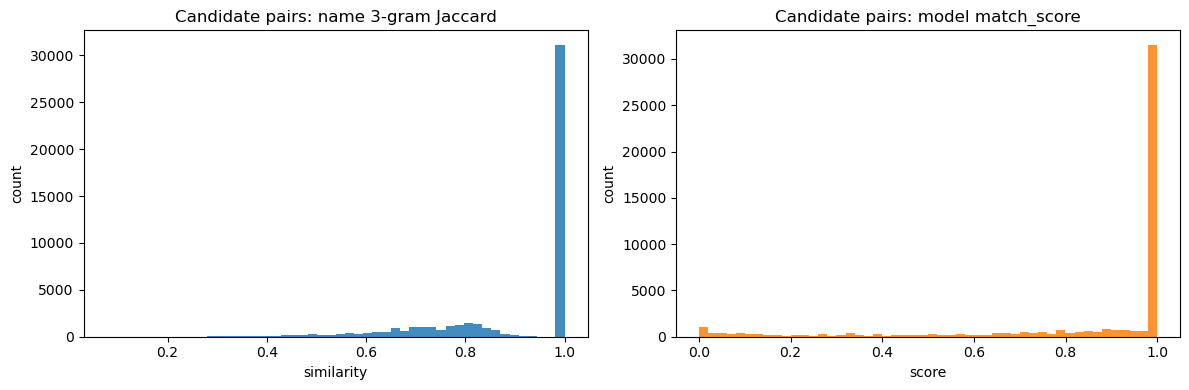

Score quantiles:
0.00    0.000032
0.25    0.833144
0.50    0.996427
0.75    0.998680
0.90    0.999257
0.95    0.999726
0.99    0.999764
1.00    0.999764
Name: match_score, dtype: float64


In [17]:
all_X = pairs_feat_df[feat_cols].values
pairs_feat_df['match_score'] = clf.predict_proba(all_X)[:, 1]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(pairs_feat_df['name_jaccard_3gram'].values, bins=50, color='#1f77b4', alpha=0.85)
ax[0].set_title('Candidate pairs: name 3-gram Jaccard')
ax[0].set_xlabel('similarity')
ax[0].set_ylabel('count')

ax[1].hist(pairs_feat_df['match_score'].values, bins=50, color='#ff7f0e', alpha=0.85)
ax[1].set_title('Candidate pairs: model match_score')
ax[1].set_xlabel('score')
ax[1].set_ylabel('count')

plt.tight_layout()
plt.show()

print('Score quantiles:')
print(pairs_feat_df['match_score'].quantile([0,0.25,0.5,0.75,0.9,0.95,0.99,1.0]))


## 9) (Optional) Export scored pairs

If you want to take the output into review tooling, export the scored candidate pairs.


In [18]:
out_cols = ['id1','id2'] + feat_cols + ['match_score','weak_label']
scored_pairs_df = pairs_feat_df[out_cols].copy()

scored_pairs_df.to_csv('candidate_pairs_scored.csv', index=False)

print('Saved candidate_pairs_scored.csv')
print(scored_pairs_df.head())


Saved candidate_pairs_scored.csv
    id1   id2  name_jaccard_3gram  name_token_jaccard  num_overlap  \
0  4003  6727            0.702128                 0.6          0.0   
1  2711  3960            0.428571                 0.6          0.0   
2  8332  8402            1.000000                 1.0          0.0   
3   147   576            1.000000                 1.0          0.0   
4  7249  7472            1.000000                 1.0          1.0   

   pack_type_eq  pack_mat_eq  net_close  match_score  weak_label  
0             1            0          0     0.586304         NaN  
1             1            0          0     0.091735         NaN  
2             1            0          0     0.998680         1.0  
3             0            0          0     0.996427         NaN  
4             0            0          0     0.996922         1.0  


## 10) Summary: What this POC notebook does and why

This notebook is a **proof-of-concept (POC) product matching system** built from the `standardized_products.csv` file. The goal of the POC is to show an end-to-end path from raw product records to a **candidate pair set** and a **baseline match scoring model**.

### The approach we took (high level)

We treated product matching as a **pairwise classification problem**. For any two product records, the model’s job is to estimate a probability-like score that they represent the *same underlying product*.

The key constraint is scale. With ~10k products, comparing every possible pair would be too expensive (it grows quadratically). So the backbone of the POC is a two-stage approach: first **generate candidate pairs** that are plausibly the same product, then **score** those candidates.

### Step-by-step: what we did in this notebook

#### Step 1: Load the dataset and sanity-check quality
We load `standardized_products.csv` and compute missingness/uniqueness by column. This tells us which attributes are reliable enough to use. In this dataset, `net_content_value` and `net_content_unit` are often missing, so the POC relies more heavily on text and packaging fields.

#### Step 2: Create a canonical text field and normalize it
Products can be described in multiple columns (commercial name, short name, description, etc.). We build a single canonical field (`name_raw`) by taking the first non-empty value from a preferred list of columns, then normalize it into `name_norm` by lowercasing and removing punctuation/noise. We also normalize `brand` into `brand_norm`.

#### Step 3: Candidate generation (blocking + nearest neighbors)
We reduce the search space by creating candidate pairs using blocking and retrieval:

- We **block by brand** for the largest brands.
- Within each brand block, we represent `name_norm` using **character n-gram TF-IDF**.
- We use **cosine nearest neighbors** to propose the most similar product names.
- For the long tail of brands, we use a simpler block on the first token of the name.

The output of this stage is `pairs_df`, a set of candidate product pairs that is far smaller than all possible pairs.

#### Step 4: Feature engineering for pairs
For each candidate pair we compute lightweight similarity signals:

- Character 3-gram Jaccard similarity on `name_norm`
- Token-level Jaccard similarity on `name_norm`
- Numeric overlap (helps detect sizes, counts, variants)
- Packaging equality flags (type/material)
- Net content closeness when present

These become the feature set for modeling.

#### Step 5: Weak supervision to bootstrap labels
Because this file does not contain explicit ground-truth matches, we build **high-confidence pseudo-labels**:

- *Weak positives*: very high text similarity plus some corroboration from packaging/numbers
- *Weak negatives*: low text similarity with disagreement signals

This is intentionally conservative and is meant to train a first baseline model.

#### Step 6: Train a baseline match model
We train a **Logistic Regression** classifier on the weakly-labeled pairs. This gives us a fast, interpretable baseline and a scoring function (`match_score`) we can apply to all candidate pairs.

We also plot distributions (similarity and match_score) to understand how separable the candidate set looks.

#### Step 7: Score all candidate pairs and export
We score every candidate pair and optionally export `candidate_pairs_scored.csv` so you can review matches externally or feed downstream clustering.

### What this POC is and is not

This POC demonstrates the full pipeline mechanics and provides a baseline scoring model. It is not yet a production-grade matcher because it does not use human-verified labels and it does not include a final clustering / entity-resolution step to turn pair scores into deduplicated product groups.

### Recommended next upgrades

If you want to turn this into a stronger system, the next improvements are:

- Replace weak labels with a **human-labeled training set** (even a few thousand pairs helps a lot)
- Add a **hard-negative mining** strategy (near-miss pairs within the same brand)
- Upgrade the model to **Gradient Boosting** (e.g., LightGBM/XGBoost) once labels are available
- Add a **clustering step** (connected components or hierarchical clustering) on high-confidence edges to form product groups
